In [1]:
import pandas as pd
import numpy as np
import yaml

In [2]:
df_train = pd.read_csv("/home/ir-rous1/rds/rds-ukaea-ap002-mOlK9qn0PlQ/ir-rous1/output/cnn-baseline/fairmast-data-preprocessing/artifacts/stats_mean_std/shot_statistics_train_NEW.csv").sort_values(by=["shot_idx", "variable"])

In [3]:
df_train

,shot_idx,shot_id,variable,length_shot,mean,variance
31,0,21719,equilibrium-beta_normal,109.0,5.095252e-01,1.593657e-01
30,0,21719,equilibrium-beta_pol,109.0,1.185680e-01,1.826368e-02
29,0,21719,equilibrium-beta_tor,109.0,1.070841e+00,4.205053e-01
33,0,21719,equilibrium-bphi_rmag,109.0,-5.542877e-01,1.084372e-03
32,0,21719,equilibrium-bvac_rmag,109.0,-4.745352e-01,1.606362e-03
...,...,...,...,...,...,...
361096,9258,27816,spectrometer_visible-filter_spectrometer_dalph...,30600.0,2.384913e-01,1.027109e-01
361076,9258,27816,summary-ip,2448.0,3.569259e+05,7.112180e+10
361075,9258,27816,summary-power_nbi,2448.0,1.642777e+06,2.842651e+12
361100,9258,27816,thomson_scattering-n_e,123.0,2.171776e+19,2.387501e+38


In [4]:
global_mean = (
    df_train
    .groupby("variable")[["length_shot", "mean", ]]
    .apply(lambda g: (g["mean"] * g["length_shot"]).sum() / g["length_shot"].sum())
    .rename("global_mean")
)
df_train_with_group_mean = df_train.join(global_mean, on="variable")

global_variance = (
    df_train_with_group_mean
    .groupby("variable")[["length_shot", "mean", "variance", "global_mean"]]
    .apply(lambda g: ( (g["length_shot"]-1) * g["variance"] + g["length_shot"] * (g["mean"]-g["global_mean"])**2 ).sum() / g["length_shot"].sum())
    .rename("global_variance")
)
df_train_with_group_mean_and_variance = df_train_with_group_mean.join(global_variance, on="variable")

In [5]:
df_train_with_group_mean_and_variance["z_score"] = (df_train_with_group_mean_and_variance["mean"] - df_train_with_group_mean_and_variance["global_mean"]) / ( np.sqrt(df_train_with_group_mean_and_variance["global_variance"]) / np.sqrt(df_train_with_group_mean_and_variance["length_shot"]) )
df_train_with_group_mean_and_variance


print( 'Count of z-6 outliers', sum ( abs(df_train_with_group_mean_and_variance["z_score"]) > 6 ) )
print( 'Count of z-12 outliers', sum ( abs(df_train_with_group_mean_and_variance["z_score"]) > 12 ) )
df_train_with_group_mean_and_variance["outlier_z_6"] = abs(df_train_with_group_mean_and_variance["z_score"]) > 6 
df_train_with_group_mean_and_variance["outlier_z_12"] = abs(df_train_with_group_mean_and_variance["z_score"]) > 12

df_train_extended = df_train_with_group_mean_and_variance.copy()


Count of z-6 outliers 133758
Count of z-12 outliers 81243


In [6]:
# import matplotlib.pyplot as plt

# plt.hist(df_train_with_group_mean_and_variance["z_score"], bins=30)
# plt.xlabel("z_score")
# plt.ylabel("Frequency")
# plt.title("Histogram of z-scores")
# plt.show()

In [7]:
df_train_extended.head()

,shot_idx,shot_id,variable,length_shot,mean,variance,global_mean,global_variance,z_score,outlier_z_6,outlier_z_12
31,0,21719,equilibrium-beta_normal,109.0,0.509525,0.159366,1.011904,2.260917,-3.488204,False,False
30,0,21719,equilibrium-beta_pol,109.0,0.118568,0.018264,0.212163,0.120479,-2.815213,False,False
29,0,21719,equilibrium-beta_tor,109.0,1.070841,0.420505,2.413701,14.551279,-3.675305,False,False
33,0,21719,equilibrium-bphi_rmag,109.0,-0.554288,0.001084,-0.513486,0.039536,-2.142371,False,False
32,0,21719,equilibrium-bvac_rmag,109.0,-0.474535,0.001606,-0.444512,0.028272,-1.864208,False,False


In [8]:
# OG global mean and variance
global_mean = (
    df_train_extended
    .groupby("variable")[["length_shot", "mean"]]
    .apply(lambda g: (g["mean"] * g["length_shot"]).sum() / g["length_shot"].sum())
    .rename("global_mean")
)
global_variance = (
    df_train_extended
    .groupby("variable")[["length_shot", "mean", "variance", "global_mean"]]
    .apply(lambda g: ( (g["length_shot"]-1) * g["variance"] + g["length_shot"] * (g["mean"]-g["global_mean"])**2 ).sum() / g["length_shot"].sum())
    .rename("global_variance")
)

# global mean and variance without the 6-z outliers
global_mean_no_z_6 = (
    df_train_extended[~df_train_extended['outlier_z_6']]
    .groupby("variable")[["length_shot", "mean"]]
    .apply(lambda g: (g["mean"] * g["length_shot"]).sum() / g["length_shot"].sum())
    .rename("global_mean_no_z_6")
)
global_variance_no_z_6 = (
    df_train_extended[~df_train_extended['outlier_z_6']]
    .groupby("variable")[["length_shot", "mean", "variance", "global_mean"]]
    .apply(lambda g: ( (g["length_shot"]-1) * g["variance"] + g["length_shot"] * (g["mean"]-g["global_mean"])**2 ).sum() / g["length_shot"].sum())
    .rename("global_variance_no_z_6")
)


In [9]:
# Merge all the stats into a single DataFrame
df_stats = pd.DataFrame({
    "variable": global_mean.index,
    "mean_all": global_mean.values,
    "std_all": np.sqrt(global_variance.values),
    "mean_no_outliers_z6": global_mean_no_z_6.values,
    "std_no_outliers_z6": np.sqrt(global_variance_no_z_6.values),
})

# Build the dictionary for YAML
final_dict = {}
for _, row in df_stats.iterrows():
    var = row["variable"]
    final_dict[var] = {
        "mean": {
            "all": row["mean_all"],
            "no_outliers_z6": row["mean_no_outliers_z6"],
            # "no_outliers_z12": row["mean_no_outliers_z12"]
        },
        "std": {
            "all": row["std_all"],
            "no_outliers_z6": row["std_no_outliers_z6"],
            # "no_outliers_z12": row["std_no_outliers_z12"]
        }
    }

# Write to YAML
with open("mean_std_train.yaml", "w") as f:
    yaml.dump(final_dict, f, sort_keys=False)


In [10]:
df_train = pd.read_csv("/home/ir-rous1/rds/rds-ukaea-ap002-mOlK9qn0PlQ/ir-rous1/output/cnn-baseline/fairmast-data-preprocessing/artifacts/stats_mean_std/shot_statistics_train_NEW.csv").sort_values(by=["shot_idx", "variable"])
df_val = pd.read_csv("/home/ir-rous1/rds/rds-ukaea-ap002-mOlK9qn0PlQ/ir-rous1/output/cnn-baseline/fairmast-data-preprocessing/artifacts/stats_mean_std/shot_statistics_val_NEW.csv").sort_values(by=["shot_idx", "variable"])
df_test = pd.read_csv("/home/ir-rous1/rds/rds-ukaea-ap002-mOlK9qn0PlQ/ir-rous1/output/cnn-baseline/fairmast-data-preprocessing/artifacts/stats_mean_std/shot_statistics_test_NEW.csv").sort_values(by=["shot_idx", "variable"])

df_all = pd.concat([df_train, df_val, df_test])
print(df_all.shape)

(451347, 6)


In [11]:
df_all_with_stats = df_all.join(global_mean, on="variable").join(global_variance, on="variable")
df_all_with_stats

df_all_with_stats["z_score"] = (df_all_with_stats["mean"] - df_all_with_stats["global_mean"]) / ( np.sqrt(df_all_with_stats["global_variance"]) / np.sqrt(df_all_with_stats["length_shot"]) )

df_all_with_stats["outlier_z_12"] = abs(df_all_with_stats["z_score"]) > 12

print( 'Count of z-12 outliers', sum ( df_all_with_stats["outlier_z_12"] ) )
print( f'Spanning {len( df_all_with_stats[ df_all_with_stats["outlier_z_12"]==True ]["variable"].unique() )} variables (out of {len( df_all_with_stats["variable"].unique()) })' )
print( f'Spanning {len( df_all_with_stats[ df_all_with_stats["outlier_z_12"]==True ]["shot_id"].unique() )} shots (out of {len( df_all_with_stats["shot_id"].unique()) })' )


Count of z-12 outliers 101731
Spanning 37 variables (out of 39)
Spanning 11572 shots (out of 11573)


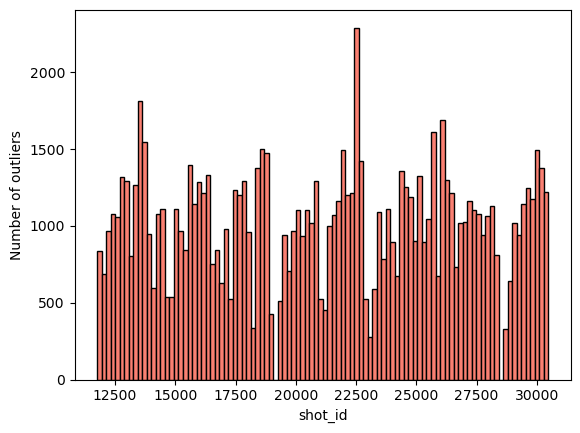

In [27]:
import matplotlib.pyplot as plt

plt.hist(
    df_all_with_stats[df_all_with_stats["outlier_z_12"]]["shot_id"],
    bins=100,
    color="salmon",
    edgecolor="black"
)
plt.xlabel("shot_id")
plt.ylabel("Number of outliers")
plt.show()


In [33]:
outlier_dict = (
    df_all_with_stats[df_all_with_stats["outlier_z_12"]].groupby("shot_id")["variable"]
    .apply(list)
    .to_dict()
)
print(outlier_dict)

with open("dict_outlier_metadata.yaml", "w") as f_:
    yaml.dump(outlier_dict, f_, sort_keys=False)

{11766: ['equilibrium-x_point_r', 'magnetics-b_field_tor_probe_saddle_voltage', 'pulse_schedule-n_e_line', 'spectrometer_visible-filter_spectrometer_dalpha_voltage'], 11767: ['equilibrium-x_point_r', 'magnetics-b_field_tor_probe_saddle_voltage', 'pulse_schedule-n_e_line', 'spectrometer_visible-filter_spectrometer_dalpha_voltage'], 11768: ['equilibrium-x_point_r', 'magnetics-b_field_tor_probe_saddle_voltage', 'pulse_schedule-n_e_line', 'spectrometer_visible-filter_spectrometer_dalpha_voltage'], 11769: ['equilibrium-x_point_r', 'magnetics-b_field_tor_probe_saddle_voltage', 'pulse_schedule-n_e_line', 'spectrometer_visible-filter_spectrometer_dalpha_voltage'], 11771: ['equilibrium-x_point_r', 'magnetics-b_field_tor_probe_saddle_voltage', 'pulse_schedule-n_e_line', 'spectrometer_visible-filter_spectrometer_dalpha_voltage'], 11772: ['equilibrium-x_point_r', 'magnetics-b_field_tor_probe_saddle_voltage', 'pulse_schedule-n_e_line', 'soft_x_rays-horizontal_cam_lower', 'spectrometer_visible-filte

In [38]:
outlier_dict.keys()

dict_keys([11766, 11767, 11768, 11769, 11771, 11772, 11773, 11774, 11775, 11776, 11777, 11779, 11780, 11789, 11790, 11791, 11794, 11795, 11796, 11797, 11798, 11799, 11802, 11804, 11805, 11806, 11807, 11808, 11809, 11810, 11811, 11812, 11815, 11816, 11817, 11818, 11819, 11820, 11821, 11822, 11823, 11824, 11825, 11826, 11827, 11829, 11830, 11831, 11833, 11834, 11835, 11836, 11837, 11838, 11840, 11841, 11847, 11848, 11849, 11850, 11851, 11852, 11855, 11856, 11857, 11859, 11860, 11862, 11866, 11867, 11868, 11870, 11871, 11872, 11873, 11874, 11876, 11878, 11879, 11880, 11889, 11890, 11891, 11892, 11893, 11894, 11895, 11896, 11897, 11898, 11899, 11901, 11902, 11903, 11905, 11906, 11908, 11911, 11912, 11913, 11914, 11915, 11916, 11917, 11918, 11919, 11920, 11921, 11922, 11923, 11924, 11925, 11926, 11927, 11930, 11931, 11932, 11933, 11934, 11935, 11936, 11937, 11938, 11939, 11940, 11941, 11942, 11943, 11944, 11945, 11946, 11948, 11949, 11950, 11951, 11952, 11953, 11954, 11955, 11956, 11957, 11